Installing pandas

In [3]:
pip install pandas

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\PriyadharshiniR\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Dataset Overview

In [4]:
import pandas as pd

df = pd.read_csv("Electricity_Consumption_Prediction.csv")

df.shape

(15000, 38)

Data Types & Info

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 38 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   household_id                15000 non-null  str    
 1   household_size              15000 non-null  int64  
 2   num_adults                  15000 non-null  int64  
 3   num_children                15000 non-null  int64  
 4   home_ownership              15000 non-null  str    
 5   house_type                  15000 non-null  str    
 6   income_bracket              15000 non-null  str    
 7   square_footage              14400 non-null  float64
 8   num_bedrooms                15000 non-null  int64  
 9   num_bathrooms               15000 non-null  float64
 10  house_age_years             15000 non-null  int64  
 11  insulation_quality          15000 non-null  str    
 12  num_floors                  15000 non-null  int64  
 13  has_basement                15000 non-null

Missing Values Check

In [6]:
df.isnull().sum()

household_id                     0
household_size                   0
num_adults                       0
num_children                     0
home_ownership                   0
house_type                       0
income_bracket                   0
square_footage                 600
num_bedrooms                     0
num_bathrooms                    0
house_age_years                  0
insulation_quality               0
num_floors                       0
has_basement                     0
heating_type                     0
cooling_type                  1561
thermostat_setting_winter      600
thermostat_setting_summer        0
climate_zone                     0
num_refrigerators                0
has_dishwasher                   0
has_washer_dryer                 0
has_electric_water_heater        0
has_pool                         0
has_spa_hot_tub                  0
num_tvs                          0
num_computers                    0
has_smart_thermostat             0
has_led_lighting    

Show Only Columns with Missing Values

In [7]:
df.isnull().sum()[df.isnull().sum() > 0]

square_footage                600
cooling_type                 1561
thermostat_setting_winter     600
avg_daily_hours_home          600
dtype: int64

Handle Categorical Missing Values

In [8]:
df['cooling_type'] = df['cooling_type'].fillna('No_Cooling')

Outlier Detection

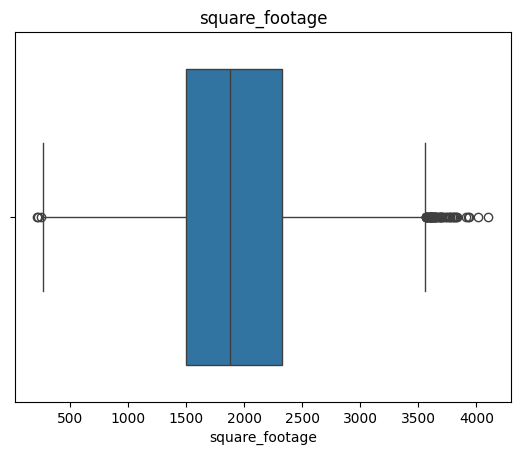

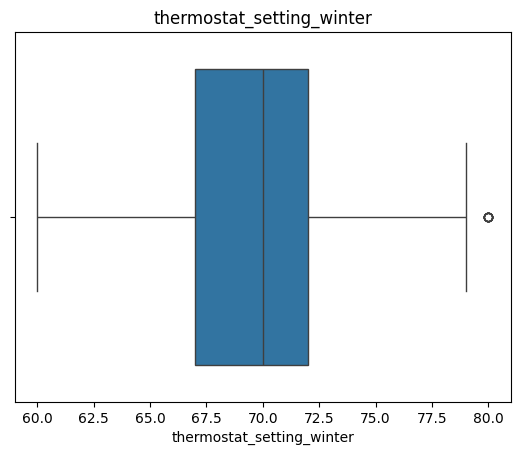

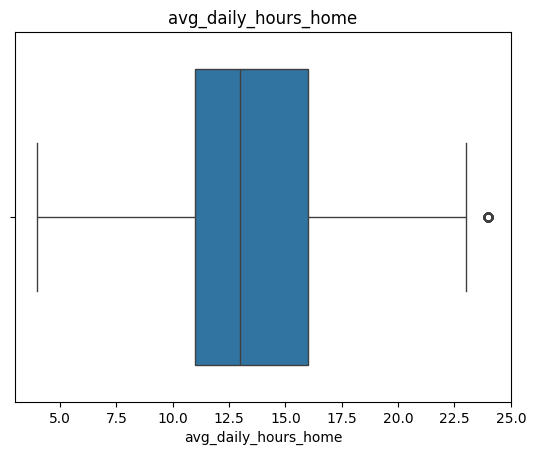

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = ['square_footage', 'thermostat_setting_winter', 'avg_daily_hours_home']

for col in cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

Handle Numerical Missing Values

In [10]:
cols = ['square_footage', 'thermostat_setting_winter', 'avg_daily_hours_home']

for col in cols:
    df[col] = df[col].fillna(df[col].median())

Drop Unnecessary Column

In [11]:
df = df.drop('household_id', axis=1)

Final Null Check

In [12]:
df.isnull().sum()

household_size                0
num_adults                    0
num_children                  0
home_ownership                0
house_type                    0
income_bracket                0
square_footage                0
num_bedrooms                  0
num_bathrooms                 0
house_age_years               0
insulation_quality            0
num_floors                    0
has_basement                  0
heating_type                  0
cooling_type                  0
thermostat_setting_winter     0
thermostat_setting_summer     0
climate_zone                  0
num_refrigerators             0
has_dishwasher                0
has_washer_dryer              0
has_electric_water_heater     0
has_pool                      0
has_spa_hot_tub               0
num_tvs                       0
num_computers                 0
has_smart_thermostat          0
has_led_lighting              0
has_energy_star_appliances    0
has_solar_panels              0
energy_audit_done             0
avg_dail

Identify Categorical Columns

In [13]:
categorical_cols = df.select_dtypes(include=['object']).columns
categorical_cols

C:\Users\PriyadharshiniR\AppData\Local\Temp\ipykernel_13772\2528409226.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


Index(['home_ownership', 'house_type', 'income_bracket', 'insulation_quality',
       'has_basement', 'heating_type', 'cooling_type', 'climate_zone',
       'has_dishwasher', 'has_washer_dryer', 'has_electric_water_heater',
       'has_pool', 'has_spa_hot_tub', 'has_smart_thermostat',
       'has_led_lighting', 'has_energy_star_appliances', 'has_solar_panels',
       'energy_audit_done', 'works_from_home', 'peak_usage_time',
       'high_consumption'],
      dtype='str')

Understand Unique Values

In [14]:
for col in categorical_cols:
    print(f"\nColumn: {col}")
    print(df[col].unique())


Column: home_ownership
<StringArray>
['Rent', 'Own']
Length: 2, dtype: str

Column: house_type
<StringArray>
['Single Family', 'Apartment', 'Townhouse', 'Condo']
Length: 4, dtype: str

Column: income_bracket
<StringArray>
['$40k-$75k', '$75k-$120k', '<$40k', '$120k+']
Length: 4, dtype: str

Column: insulation_quality
<StringArray>
['Fair', 'Good', 'Excellent', 'Poor']
Length: 4, dtype: str

Column: has_basement
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

Column: heating_type
<StringArray>
['Electric', 'Gas', 'Heat Pump', 'Oil', 'Other']
Length: 5, dtype: str

Column: cooling_type
<StringArray>
['Central AC', 'Window Units', 'Heat Pump', 'No_Cooling']
Length: 4, dtype: str

Column: climate_zone
<StringArray>
['Mixed', 'Hot', 'Moderate', 'Cold']
Length: 4, dtype: str

Column: has_dishwasher
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

Column: has_washer_dryer
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

Column: has_electric_water_heater
<StringArray>
['No', 'Yes']
Len

Label Encoding (Binary)

In [15]:
binary_cols = [
    'home_ownership','has_basement','has_dishwasher','has_washer_dryer',
    'has_electric_water_heater','has_pool','has_spa_hot_tub',
    'has_smart_thermostat','has_led_lighting','has_energy_star_appliances',
    'has_solar_panels','energy_audit_done','works_from_home','high_consumption'
]

for col in binary_cols:
    df[col] = df[col].map({'Yes':1, 'No':0, 'Own':1, 'Rent':0})

Ordinal Encoding

In [16]:
# Income mapping
income_map = {
    '<$40k': 0,
    '$40k-$75k': 1,
    '$75k-$120k': 2,
    '$120k+': 3
}

df['income_bracket'] = df['income_bracket'].map(income_map)

# Insulation mapping
insulation_map = {
    'Poor': 0,
    'Fair': 1,
    'Good': 2,
    'Excellent': 3
}

df['insulation_quality'] = df['insulation_quality'].map(insulation_map)

One-Hot Encoding

In [17]:
nominal_cols = [
    'house_type', 'heating_type', 'cooling_type',
    'climate_zone', 'peak_usage_time'
]

df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

Final Check

In [18]:
df.select_dtypes(include=['object']).columns

Index([], dtype='str')

FEATURE ENGINEERING

Household Load

In [19]:
df['total_occupants'] = df['num_adults'] + df['num_children']
df['total_occupants'] = df['total_occupants'].replace(0, 1)

Area Efficiency

In [20]:
df['area_per_person'] = df['square_footage'] / df['total_occupants']

Appliance Load

In [21]:
df['total_appliances'] = (
    df['num_refrigerators'] +
    df['num_tvs'] +
    df['num_computers']
)

Time at Home

In [22]:
df['home_usage_index'] = df['avg_daily_hours_home'] * df['total_occupants']

HVAC Load

In [23]:
df['temp_diff'] = df['thermostat_setting_summer'] - df['thermostat_setting_winter']

Luxury Indicator

In [24]:
df['luxury_index'] = df['has_pool'] + df['has_spa_hot_tub']

HYPOTHESIS TESTING

Insulation Quality
## Hypothesis 1: Insulation Quality impacts Electricity Consumption

- H0: Insulation quality has no effect
- H1: Insulation quality significantly affects electricity consumption

In [25]:
from scipy.stats import f_oneway
from scipy.stats import pearsonr


groups = [
    df[df['insulation_quality'] == 0]['monthly_kwh_consumption'],
    df[df['insulation_quality'] == 1]['monthly_kwh_consumption'],
    df[df['insulation_quality'] == 2]['monthly_kwh_consumption'],
    df[df['insulation_quality'] == 3]['monthly_kwh_consumption']
]

f_stat, p_value = f_oneway(*groups)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 120.90365920636847
P-value: 2.256745654080168e-77


Appliances vs Consumption
## Hypothesis 2: Number of Appliances impacts Electricity Consumption

- H0: Number of appliances has no effect
- H1: Number of appliances significantly affects electricity consumption

In [26]:
corr, p_value = pearsonr(df['total_appliances'], df['monthly_kwh_consumption'])

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: 0.0063119320982401115
P-value: 0.4395259774362589


Household Size vs Consumption
## Hypothesis 3: Household Size impacts Electricity Consumption

- H0 (Null Hypothesis): Household size has no effect on electricity consumption
- H1 (Alternative Hypothesis): Household size significantly affects electricity consumption

In [27]:

corr, p_value = pearsonr(df['household_size'], df['monthly_kwh_consumption'])

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: 0.769704048494126
P-value: 0.0


Work From Home Effect (T-Test)
## Hypothesis 4: Work From Home impacts Electricity Consumption

- H0: No difference in consumption between WFH and non-WFH households
- H1: Significant difference exists

In [28]:
from scipy.stats import ttest_ind

wfh = df[df['works_from_home'] == 1]['monthly_kwh_consumption']
non_wfh = df[df['works_from_home'] == 0]['monthly_kwh_consumption']

t_stat, p_value = ttest_ind(wfh, non_wfh)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 12.210995368439727
P-value: 3.943467966160481e-34


Climate Zone Impact
## Hypothesis 5: Climate Zone impacts Electricity Consumption

- H0: No difference across climate zones
- H1: At least one climate zone differs

In [29]:
groups = []

for col in df.columns:
    if "climate_zone_" in col:
        groups.append(df[df[col] == 1]['monthly_kwh_consumption'])

f_stat, p_value = f_oneway(*groups)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 386.0453540154124
P-value: 6.84164084022597e-163


Exploratory Data Analysis (EDA)

## Distribution of Electricity Consumption

We analyze the distribution of monthly electricity consumption to understand its spread and skewness.

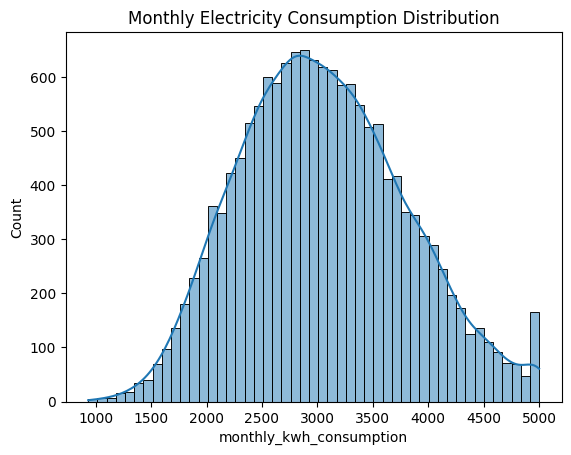

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['monthly_kwh_consumption'], kde=True)
plt.title("Monthly Electricity Consumption Distribution")
plt.show()

## Household Size vs Electricity Consumption

We analyze how the number of occupants affects electricity usage.

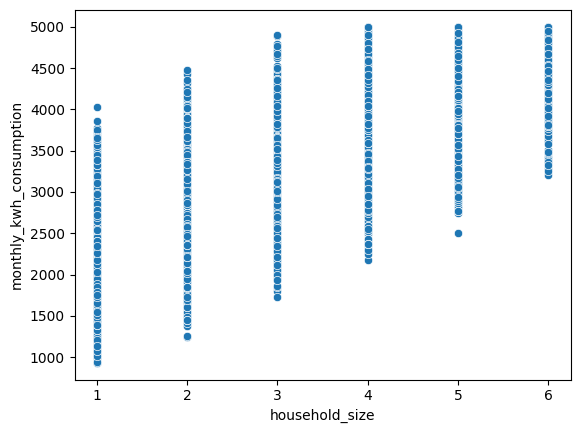

In [31]:
sns.scatterplot(x='household_size', y='monthly_kwh_consumption', data=df)
plt.show()

## Insulation Quality vs Electricity Consumption

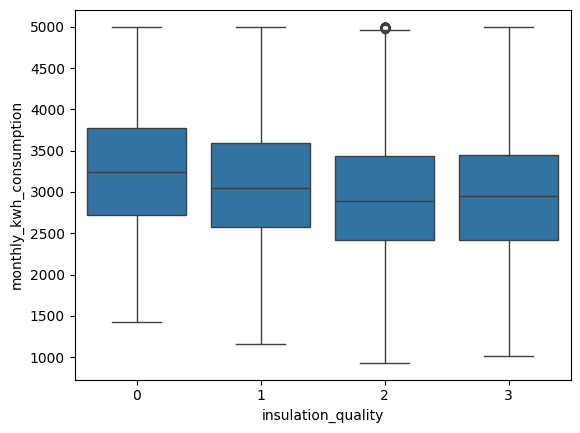

In [32]:
sns.boxplot(x='insulation_quality', y='monthly_kwh_consumption', data=df)
plt.show()

## Work From Home vs Electricity Consumption

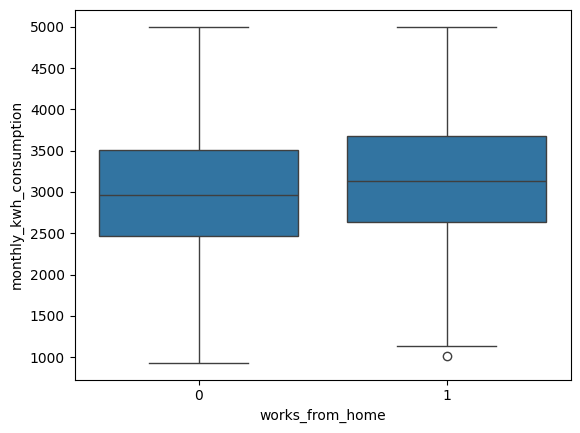

In [33]:
sns.boxplot(x='works_from_home', y='monthly_kwh_consumption', data=df)
plt.show()

## Climate Zone vs Electricity Consumption

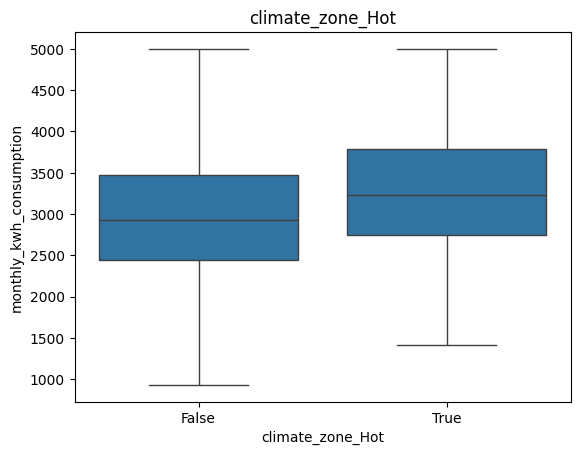

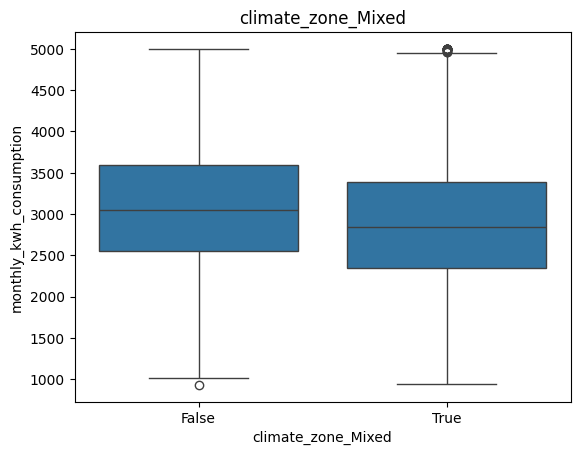

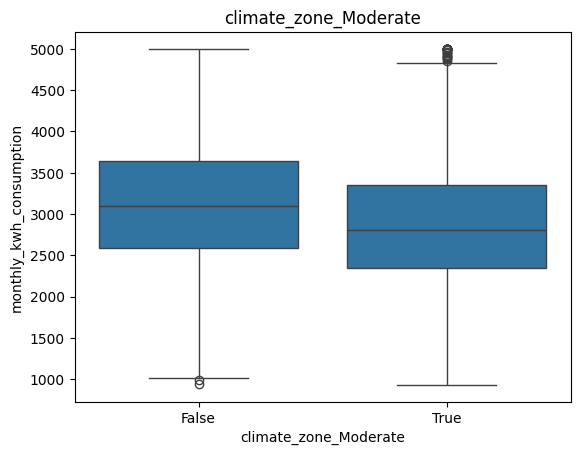

In [34]:
# If one-hot encoded
climate_cols = [col for col in df.columns if "climate_zone_" in col]

for col in climate_cols:
    sns.boxplot(x=df[col], y=df['monthly_kwh_consumption'])
    plt.title(col)
    plt.show()

## Correlation Heatmap

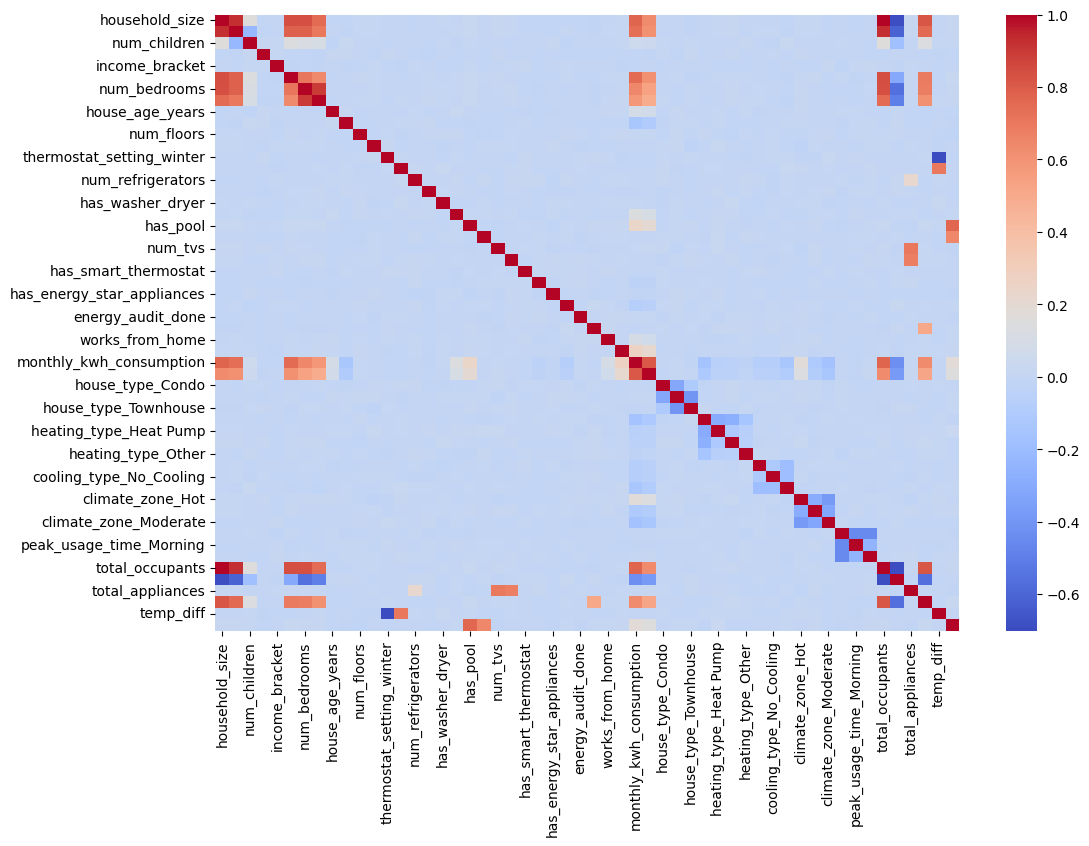

In [35]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()